In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import string
import random
import pickle
import zipfile

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GRU, Embedding, Dropout, add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)

print("GPUs available:", tf.config.list_physical_devices('GPU'))

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

2026-04-29 17:00:20.203501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777482020.226941  556301 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777482020.234820  556301 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777482020.253022  556301 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777482020.253048  556301 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777482020.253051  556301 computation_placer.cc:177] computation placer alr

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os

DATASET_PATH = '/kaggle/input/datasets/hariwh0/ms-coco-dataset'

IMAGE_FOLDER = os.path.join(DATASET_PATH, 'train2014', 'train2014')

ANNOTATION_FILE = os.path.join(
    DATASET_PATH,
    'captions',
    'annotations',
    'captions_train2014.json'
)

INSTANCE_FILE = os.path.join(
    DATASET_PATH,
    'captions',
    'annotations',
    'instances_train2014.json'
)

print("Image folder exists:", os.path.exists(IMAGE_FOLDER))
print("Annotation file exists:", os.path.exists(ANNOTATION_FILE))
print("Sample image files:", os.listdir(IMAGE_FOLDER)[:5])

Image folder exists: True
Annotation file exists: True
Sample image files: ['COCO_train2014_000000263229.jpg', 'COCO_train2014_000000381595.jpg', 'COCO_train2014_000000147733.jpg', 'COCO_train2014_000000559395.jpg', 'COCO_train2014_000000374072.jpg']


In [3]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [4]:
# ============================================================
# 3. Load Captions
# ============================================================

with open(ANNOTATION_FILE, 'r') as f:
    data = json.load(f)

captions = {}

for item in data['annotations']:
    image_id = item['image_id']
    caption = item['caption']

    if image_id not in captions:
        captions[image_id] = []

    captions[image_id].append(caption)

print(f'Total images with captions: {len(captions):,}')

Total images with captions: 82,783


In [5]:
with open(INSTANCE_FILE, 'r') as f:
    inst_data = json.load(f)

# image_id -> 80-dim multi-hot vector
aux_labels = {}

# map category ids to indices 0..79
cat_ids = sorted([c['id'] for c in inst_data['categories']])
cat_to_idx = {cid: i for i, cid in enumerate(cat_ids)}

for ann in inst_data['annotations']:
    img_id = ann['image_id']
    cat_id = ann['category_id']

    if img_id not in aux_labels:
        aux_labels[img_id] = np.zeros(80, dtype=np.float32)

    aux_labels[img_id][cat_to_idx[cat_id]] = 1.0

In [6]:
# ============================================================
# 4. Use 50% Subset
# ============================================================

SUBSET_FRACTION = 1

keys = list(captions.keys())
sample_size = int(len(keys) * SUBSET_FRACTION)

selected = random.sample(keys, sample_size)
captions = {k: captions[k] for k in selected}

print(f'Using {len(captions):,} images ({SUBSET_FRACTION * 100:.0f}% of dataset)')

Using 82,783 images (100% of dataset)


In [7]:
# ============================================================
# 5. Caption Cleaning
# ============================================================

def clean_captions(captions_dict):
    """
    Clean captions:
      1. Lowercase
      2. Remove punctuation
      3. Keep alphabetic words only
      4. Preserve useful short words like 'a'
      5. Remove very short captions
      6. Limit very long captions
      7. Remove duplicate captions
      8. Add startseq/endseq
    """
    table = str.maketrans('', '', string.punctuation)

    for key, caps in captions_dict.items():
        cleaned_caps = []

        for cap in caps:
            cap = cap.lower()
            cap = cap.translate(table)
            cap = ' '.join(cap.split())

            words = cap.split()
            words = [w for w in words if w.isalpha()]

            if len(words) < 3:
                continue

            words = words[:18]

            cleaned_caption = 'startseq ' + ' '.join(words) + ' endseq'
            cleaned_caps.append(cleaned_caption)

        captions_dict[key] = list(set(cleaned_caps))


clean_captions(captions)

captions = {
    img_id: caps
    for img_id, caps in captions.items()
    if len(caps) > 0
}

print(f'Images after caption cleaning: {len(captions):,}')

sample_key = list(captions.keys())[0]
print('Sample cleaned caption:', captions[sample_key][0])

Images after caption cleaning: 82,783
Sample cleaned caption: startseq a courtyard area features a climbing tree climbing up a brick wall a bench and a flower bed endseq


In [8]:
# ============================================================
# 6. Train/Validation Split BEFORE Tokenizer
# ============================================================

all_keys = list(captions.keys())

train_keys, val_keys = train_test_split(
    all_keys,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

train_captions = {k: captions[k] for k in train_keys}
val_captions = {k: captions[k] for k in val_keys}

print(f'Train images: {len(train_captions):,}')
print(f'Val images  : {len(val_captions):,}')

Train images: 74,504
Val images  : 8,279


In [9]:
# ============================================================
# 7. Vocabulary Construction
# ============================================================

VOCAB_SIZE_LIMIT = 8000

train_texts = [
    cap
    for caps in train_captions.values()
    for cap in caps
]

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE_LIMIT,
    oov_token='<unk>'
)

tokenizer.fit_on_texts(train_texts)

vocab_size = min(VOCAB_SIZE_LIMIT, len(tokenizer.word_index) + 1)

caption_lengths = [len(c.split()) for c in train_texts]
max_length = int(np.percentile(caption_lengths, 95))
max_length = min(max_length, 20)

print(f'Vocabulary size: {vocab_size:,}')
print(f'Max caption length: {max_length}')

Vocabulary size: 8,000
Max caption length: 17


In [10]:
# ============================================================
# 8. Image Path Preparation
# ============================================================

image_folder = IMAGE_FOLDER + '/'

image_paths = {
    img_id: os.path.join(
        IMAGE_FOLDER,
        f'COCO_train2014_{str(img_id).zfill(12)}.jpg'
    )
    for img_id in captions.keys()
}

image_paths = {
    img_id: path
    for img_id, path in image_paths.items()
    if os.path.exists(path)
}

captions = {
    img_id: caps
    for img_id, caps in captions.items()
    if img_id in image_paths
}

train_captions = {
    img_id: caps
    for img_id, caps in train_captions.items()
    if img_id in image_paths
}

val_captions = {
    img_id: caps
    for img_id, caps in val_captions.items()
    if img_id in image_paths
}

print(f'Images with existing files: {len(captions):,}')
print(f'Train images after filtering: {len(train_captions):,}')
print(f'Val images after filtering: {len(val_captions):,}')

Images with existing files: 82,783
Train images after filtering: 74,504
Val images after filtering: 8,279


In [11]:
# ============================================================
# 9. CNN Feature Extractor
# ============================================================

base_model = ResNet50(weights='imagenet')

cnn_model = Model(
    inputs=base_model.inputs,
    outputs=base_model.layers[-2].output
)

print('CNN output shape:', cnn_model.output_shape)

I0000 00:00:1777482184.730710  556301 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


CNN output shape: (None, 2048)


In [12]:
# ============================================================
# 10. Batched Image Feature Extraction
# ============================================================

def extract_features_batch(image_paths, model, batch_size=64):
    """
    Extract ResNet50 features in batches.
    Faster than processing one image at a time.
    """
    features = {}
    image_ids = list(image_paths.keys())

    for start in range(0, len(image_ids), batch_size):
        batch_ids = image_ids[start:start + batch_size]
        batch_images = []

        for img_id in batch_ids:
            img = load_img(image_paths[img_id], target_size=(224, 224))
            img = img_to_array(img)
            batch_images.append(img)

        batch_images = np.array(batch_images)
        batch_images = preprocess_input(batch_images)

        batch_features = model.predict(batch_images, verbose=0)

        for img_id, feature in zip(batch_ids, batch_features):
            features[img_id] = np.expand_dims(feature, axis=0)

        print(f'Processed {min(start + batch_size, len(image_ids)):,} / {len(image_ids):,}')

    return features


FEATURES_PATH = '/kaggle/working/features_50_percent.pkl'

In [13]:
# ============================================================
# 11. Save or Load Features
# ============================================================

if os.path.exists(FEATURES_PATH):
    with open(FEATURES_PATH, 'rb') as f:
        features_dict = pickle.load(f)

    print(f'Loaded {len(features_dict):,} features from Kaggle working directory')

else:
    features_dict = extract_features_batch(
        image_paths,
        cnn_model,
        batch_size=64
    )

    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(features_dict, f)

    print(f'Saved {len(features_dict):,} features to Kaggle working directory')

Loaded 82,783 features from Kaggle working directory


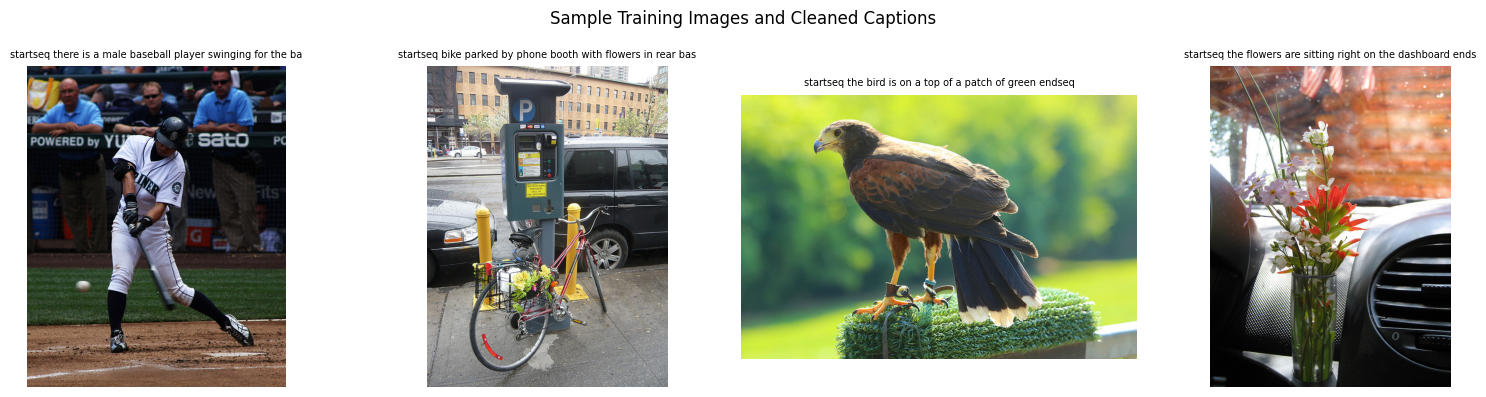

In [14]:
# ============================================================
# 12. Visual Sanity Check
# ============================================================

available_image_ids = list(set(captions.keys()) & set(features_dict.keys()))
sample_ids = random.sample(available_image_ids, min(4, len(available_image_ids)))

fig, axes = plt.subplots(1, len(sample_ids), figsize=(16, 4))

if len(sample_ids) == 1:
    axes = [axes]

for ax, img_id in zip(axes, sample_ids):
    ax.imshow(Image.open(image_paths[img_id]))
    ax.axis('off')
    ax.set_title(captions[img_id][0][:60], fontsize=7, wrap=True)

plt.suptitle('Sample Training Images and Cleaned Captions')
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 13. Sequence Generator
# ============================================================

def data_generator(captions_dict, features, tokenizer, max_length, vocab_size, batch_size=32):
    """
    Generates batches:
      X1 = image features
      X2 = partial caption sequence
      y  = next word
    """
    image_ids = list(captions_dict.keys())

    while True:
        random.shuffle(image_ids)

        X1, X2, y, aux_batch = [], [], [], []

        for image_id in image_ids:
            if image_id not in features:
                continue

            feature = features[image_id][0]

            for cap in captions_dict[image_id]:
                seq = tokenizer.texts_to_sequences([cap])[0]
                seq = [word_id for word_id in seq if word_id < vocab_size]

                if len(seq) < 2:
                    continue

                for i in range(1, len(seq)):
                    in_seq = pad_sequences(
                        [seq[:i]],
                        maxlen=max_length,
                        padding='post'
                    )[0]

                    out_seq = to_categorical(
                        [seq[i]],
                        num_classes=vocab_size
                    )[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
                    aux_batch.append(aux_labels.get(image_id, np.zeros(80)))

                    if len(X1) == batch_size:
                        yield (
                            (np.array(X1), np.array(X2)),
                            {
                                'caption_output': np.array(y),
                                'aux_output': np.array(aux_batch)
                            }
                        )

                        X1, X2, y, aux_batch = [], [], [], []

In [16]:
# ============================================================
# 14. Filter Data and Create Generators
# ============================================================

train_filtered = {
    k: v
    for k, v in train_captions.items()
    if k in features_dict
}

val_filtered = {
    k: v
    for k, v in val_captions.items()
    if k in features_dict
}

BATCH_SIZE = 32

train_generator = data_generator(
    train_filtered,
    features_dict,
    tokenizer,
    max_length,
    vocab_size,
    batch_size=BATCH_SIZE
)

val_generator = data_generator(
    val_filtered,
    features_dict,
    tokenizer,
    max_length,
    vocab_size,
    batch_size=BATCH_SIZE
)

In [17]:
# ============================================================
# 15. Count Training Sequences
# ============================================================

def count_sequences(captions_dict, features):
    total = 0

    for img_id, caps in captions_dict.items():
        if img_id not in features:
            continue

        for cap in caps:
            seq = tokenizer.texts_to_sequences([cap])[0]
            seq = [word_id for word_id in seq if word_id < vocab_size]

            if len(seq) > 1:
                total += len(seq) - 1

    return total


train_sequences = count_sequences(train_filtered, features_dict)
val_sequences = count_sequences(val_filtered, features_dict)

train_steps = train_sequences // BATCH_SIZE
val_steps = val_sequences // BATCH_SIZE

print(f'Train sequences: {train_sequences:,}')
print(f'Val sequences  : {val_sequences:,}')
print(f'Train steps/epoch: {train_steps:,}')
print(f'Val steps/epoch  : {val_steps:,}')

Train sequences: 4,248,526
Val sequences  : 471,962
Train steps/epoch: 132,766
Val steps/epoch  : 14,748


In [18]:
# ============================================================
# 16. Model Architecture
# ============================================================

NUM_COCO_CLASSES = 80

# Image branch
inputs1 = Input(shape=(2048,), name='image_input')
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(512, activation='relu')(fe1)

# Auxiliary classification branch
aux_h = Dense(128, activation='relu', name='aux_hidden')(fe1)
aux_out = Dense(NUM_COCO_CLASSES, activation='sigmoid', name='aux_output')(aux_h)

# Text branch
inputs2 = Input(shape=(max_length,), name='text_input')
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = GRU(512, use_cudnn=False)(se2)

# Decoder
merged = add([fe2, se3])
dec = Dense(256, activation='relu')(merged)

main_out = Dense(
    vocab_size,
    activation='softmax',
    name='caption_output'
)(dec)

model = Model(
    inputs=[inputs1, inputs2],
    outputs=[main_out, aux_out]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'caption_output': 'categorical_crossentropy',
        'aux_output': 'binary_crossentropy'
    },
    loss_weights={
        'caption_output': 1.0,
        'aux_output': 0.1
    }
)
early_stop = EarlyStopping(
    monitor='val_caption_output_loss',
    mode='min',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_caption_output_loss',
    mode='min',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_captioning_model.keras',
    monitor='val_caption_output_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 17, 256)   │  2,048,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 17, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 17)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 512)       │  1,182,720 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dense[0][0],      │
│                     │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_hidden (Dense)  │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_output      │ (None, 8000)      │  2,056,000 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_output (Dense)  │ (None, 80)        │     10,320 │ aux_hidden[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,739,728 (25.71 MB)

 Trainable params: 6,739,728 (25.71 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# 17. Train Model
# ============================================================


EPOCHS = 8

history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/8


I0000 00:00:1777482199.542387  556364 service.cc:152] XLA service 0x7ba80c002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777482199.542436  556364 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777482200.124878  556364 cuda_dnn.cc:529] Loaded cuDNN version 91002


    18/132766 ━━━━━━━━━━━━━━━━━━━━ 21:51 10ms/step - aux_output_loss: 0.9120 - caption_output_loss: 8.9182 - loss: 9.0094

I0000 00:00:1777482202.795739  556364 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132764/132766 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - aux_output_loss: 0.0892 - caption_output_loss: 3.7372 - loss: 3.7462
Epoch 1: val_caption_output_loss improved from inf to 3.05152, saving model to /kaggle/working/best_captioning_model.keras
132766/132766 ━━━━━━━━━━━━━━━━━━━━ 1329s 10ms/step - aux_output_loss: 0.0892 - caption_output_loss: 3.7372 - loss: 3.7462 - val_aux_output_loss: 0.0711 - val_caption_output_loss: 3.0515 - val_loss: 3.0586 - learning_rate: 1.0000e-04
Epoch 2/8
132766/132766 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - aux_output_loss: 0.0739 - caption_output_loss: 3.0266 - loss: 3.0340
Epoch 2: val_caption_output_loss improved from 3.05152 to 2.94564, saving model to /kaggle/working/best_captioning_model.keras
132766/132766 ━━━━━━━━━━━━━━━━━━━━ 1337s 10ms/step - aux_output_loss: 0.0739 - caption_output_loss: 3.0266 - loss: 3.0340 - val_aux_output_loss: 0.0739 - val_caption_output_loss: 2.9456 - val_loss: 2.9530 - learning_rate: 1.0000e-04
Epoch 3/8
132765/132766 ━━━━━━━━━━━━━

In [20]:
# ============================================================
# 18. Save Model, Tokenizer, and Preprocessing Info
# ============================================================

MODEL_PATH = '/kaggle/working/captioning_model_50_percent.h5'
TOKENIZER_PATH = '/kaggle/working/tokenizer_50_percent.pkl'
HISTORY_PATH = '/kaggle/working/training_history_50_percent.pkl'
PREPROCESSING_PATH = '/kaggle/working/preprocessing_info_50_percent.pkl'
model.save(MODEL_PATH)

with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)

with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)

preprocessing_info = {
    'vocab_size': vocab_size,
    'max_length': max_length,
    'vocab_size_limit': VOCAB_SIZE_LIMIT,
    'subset_fraction': SUBSET_FRACTION
}

with open(PREPROCESSING_PATH, 'wb') as f:
    pickle.dump(preprocessing_info, f)

print('Model, tokenizer, history, and preprocessing info saved.')

Model, tokenizer, history, and preprocessing info saved.


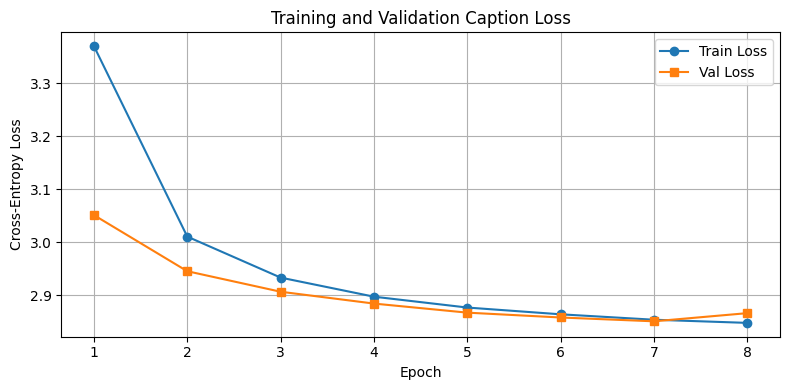

In [21]:
# ============================================================
# 19. Plot Training Curves
# ============================================================

train_loss = history.history['caption_output_loss']
val_loss = history.history['val_caption_output_loss']

epochs_x = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_x, train_loss, marker='o', label='Train Loss')
plt.plot(epochs_x, val_loss, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training and Validation Caption Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

In [22]:
# ============================================================
# 20. Caption Generation
# ============================================================

index_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}


def generate_caption_greedy(model, tokenizer, photo, max_length):
    """
    Greedy decoding.
    """
    in_text = 'startseq'

    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = [word_id for word_id in seq if word_id < vocab_size]

        seq = pad_sequences(
            [seq],
            maxlen=max_length,
            padding='post'
        )

        yhat = model.predict([photo, seq], verbose=0)[0][0]
        pred = np.argmax(yhat)

        word = index_word.get(pred)

        if word is None or word == 'endseq':
            break

        in_text += ' ' + word

    return in_text.replace('startseq', '').replace('endseq', '').strip()


print('Caption generation function ready.')


def generate_caption_beam_search(model, tokenizer, photo, max_length, beam_width=3):
    index_word = {index: word for word, index in tokenizer.word_index.items()}

    sequences = [(['startseq'], 0.0)]

    for _ in range(max_length):
        all_candidates = []

        for seq_words, score in sequences:
            if seq_words[-1] == 'endseq':
                all_candidates.append((seq_words, score))
                continue

            text = ' '.join(seq_words)

            seq = tokenizer.texts_to_sequences([text])[0]
            seq = [word_id for word_id in seq if word_id < vocab_size]
            seq = pad_sequences([seq], maxlen=max_length, padding='post')

            yhat = model.predict([photo, seq], verbose=0)[0][0]

            top_indices = np.argsort(yhat)[-beam_width:]

            for idx in top_indices:
                word = index_word.get(idx)

                if word is None:
                    continue

                candidate = (
                    seq_words + [word],
                    score - np.log(yhat[idx] + 1e-9)
                )

                all_candidates.append(candidate)

        sequences = sorted(all_candidates, key=lambda tup: tup[1])[:beam_width]

    best_seq = sequences[0][0]

    caption = ' '.join(best_seq)
    caption = caption.replace('startseq', '').replace('endseq', '').strip()

    return caption

Caption generation function ready.


In [23]:
# ============================================================
# 21. BLEU Evaluation: Greedy vs Beam Search
# ============================================================

N_EVAL = 500
smoothie = SmoothingFunction().method4

# Use the same validation images for all decoding methods
eval_ids = random.sample(
    list(val_filtered.keys()),
    min(N_EVAL, len(val_filtered))
)

def evaluate_bleu(decoding_method='greedy', beam_width=3):
    references = []
    hypotheses = []

    for img_id in eval_ids:
        photo = features_dict[img_id]

        if decoding_method == 'greedy':
            generated = generate_caption_greedy(
                model,
                tokenizer,
                photo,
                max_length
            )
            method_name = 'Greedy'

        else:
            generated = generate_caption_beam_search(
                model,
                tokenizer,
                photo,
                max_length,
                beam_width=beam_width
            )
            method_name = f'Beam {beam_width}'

        reference_list = [
            cap.replace('startseq', '').replace('endseq', '').split()
            for cap in val_filtered[img_id]
        ]

        references.append(reference_list)
        hypotheses.append(generated.split())

    b1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1, 0, 0, 0),
        smoothing_function=smoothie
    )

    b2 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smoothie
    )

    b3 = corpus_bleu(
        references,
        hypotheses,
        weights=(1/3, 1/3, 1/3, 0),
        smoothing_function=smoothie
    )

    b4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return {
        'method': method_name,
        'BLEU-1': b1,
        'BLEU-2': b2,
        'BLEU-3': b3,
        'BLEU-4': b4
    }


results = [
    evaluate_bleu(decoding_method='greedy'),
    evaluate_bleu(decoding_method='beam', beam_width=3),
    evaluate_bleu(decoding_method='beam', beam_width=5)
]

print("Evaluation Results")
print("=" * 60)

for r in results:
    print(r['method'])
    print(f"BLEU-1: {r['BLEU-1']:.4f}")
    print(f"BLEU-2: {r['BLEU-2']:.4f}")
    print(f"BLEU-3: {r['BLEU-3']:.4f}")
    print(f"BLEU-4: {r['BLEU-4']:.4f}")
    print("-" * 60)

best_result = max(results, key=lambda x: x['BLEU-4'])

bleu1 = best_result['BLEU-1']
bleu2 = best_result['BLEU-2']
bleu3 = best_result['BLEU-3']
bleu4 = best_result['BLEU-4']
best_decoding_method = best_result['method']

print("Best decoding method based on BLEU-4:")
print(f"{best_decoding_method} with BLEU-4 = {bleu4:.4f}")

Evaluation Results
Greedy
BLEU-1: 0.6130
BLEU-2: 0.4293
BLEU-3: 0.2991
BLEU-4: 0.2150
------------------------------------------------------------
Beam 3
BLEU-1: 0.6356
BLEU-2: 0.4588
BLEU-3: 0.3297
BLEU-4: 0.2396
------------------------------------------------------------
Beam 5
BLEU-1: 0.6206
BLEU-2: 0.4446
BLEU-3: 0.3216
BLEU-4: 0.2387
------------------------------------------------------------
Best decoding method based on BLEU-4:
Beam 3 with BLEU-4 = 0.2396


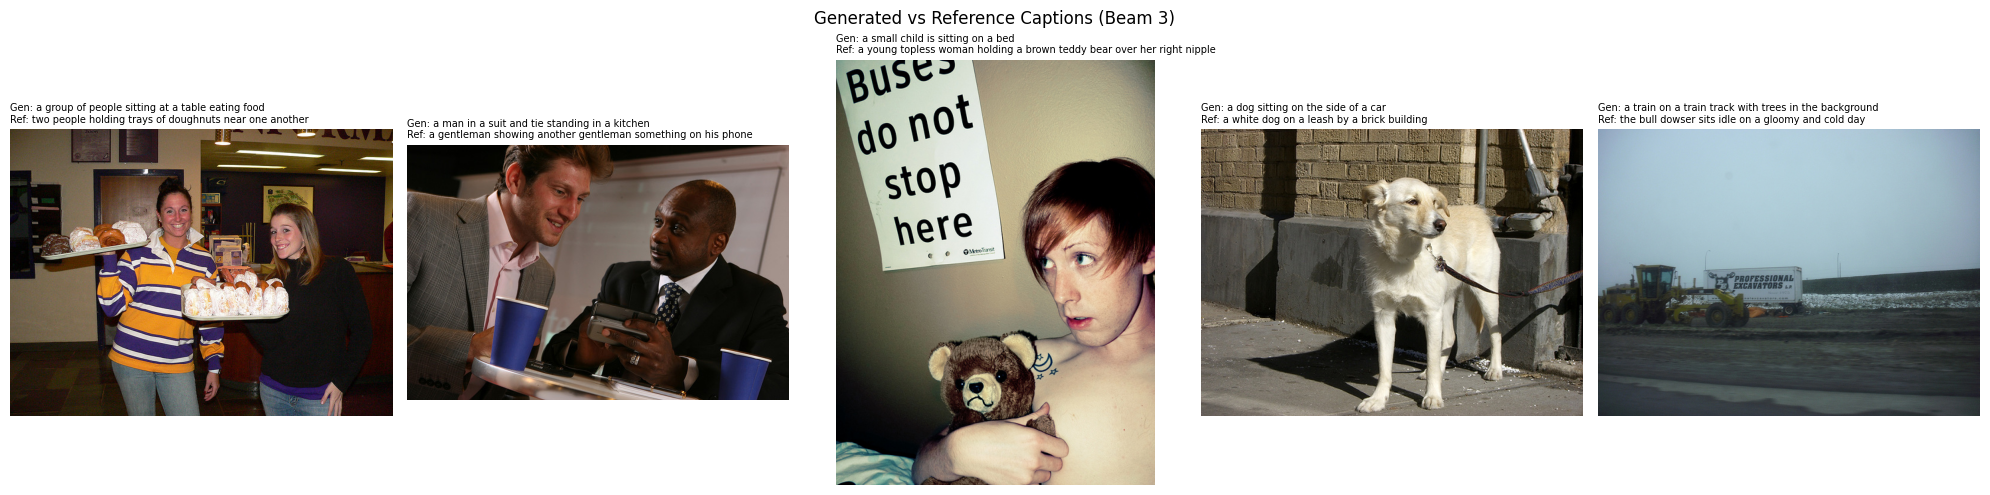

In [24]:
# ============================================================
# 22. Qualitative Results
# ============================================================

def generate_best_caption(model, tokenizer, photo, max_length):
    if best_decoding_method == 'Greedy':
        return generate_caption_greedy(
            model,
            tokenizer,
            photo,
            max_length
        )

    elif best_decoding_method == 'Beam 3':
        return generate_caption_beam_search(
            model,
            tokenizer,
            photo,
            max_length,
            beam_width=3
        )

    elif best_decoding_method == 'Beam 5':
        return generate_caption_beam_search(
            model,
            tokenizer,
            photo,
            max_length,
            beam_width=5
        )


sample_ids = random.sample(list(val_filtered.keys()), 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, img_id in zip(axes, sample_ids):
    photo = features_dict[img_id]

    generated = generate_best_caption(
        model,
        tokenizer,
        photo,
        max_length
    )

    reference = (
        val_filtered[img_id][0]
        .replace('startseq', '')
        .replace('endseq', '')
        .strip()
    )

    ax.imshow(Image.open(image_paths[img_id]))
    ax.axis('off')
    ax.set_title(
        f'Gen: {generated}\nRef: {reference}',
        fontsize=7,
        wrap=True,
        loc='left'
    )

plt.suptitle(f'Generated vs Reference Captions ({best_decoding_method})')
plt.tight_layout()
plt.savefig('qualitative_results.png', dpi=150)
plt.show()

In [25]:
# ============================================================
# 23. Final Summary
# ============================================================

print('=' * 60)
print('CNN-RNN IMAGE CAPTIONING SUMMARY')
print('=' * 60)

print(f'CNN Backbone        : ResNet50 pretrained on ImageNet')
print(f'CNN Feature Dim     : 2048')
print(f'Embedding Dim       : 256')
print(f'GRU Hidden Dim      : 512')

print(f'Subset Fraction     : {SUBSET_FRACTION * 100:.0f}%')
print(f'Vocabulary Size     : {vocab_size:,}')
print(f'Max Sequence Length : {max_length}')

print(f'Aux Classifier      : {NUM_COCO_CLASSES} COCO classes')

print(f'Train Images        : {len(train_filtered):,}')
print(f'Validation Images   : {len(val_filtered):,}')

print(f'Train Sequences     : {train_sequences:,}')
print(f'Validation Sequences: {val_sequences:,}')

print('-' * 60)
print(f'Best Decoding Method: {best_decoding_method}')

print(f'BLEU-1              : {bleu1:.4f}')
print(f'BLEU-2              : {bleu2:.4f}')
print(f'BLEU-3              : {bleu3:.4f}')
print(f'BLEU-4              : {bleu4:.4f}')

print('=' * 60)

CNN-RNN IMAGE CAPTIONING SUMMARY
CNN Backbone        : ResNet50 pretrained on ImageNet
CNN Feature Dim     : 2048
Embedding Dim       : 256
GRU Hidden Dim      : 512
Subset Fraction     : 100%
Vocabulary Size     : 8,000
Max Sequence Length : 17
Aux Classifier      : 80 COCO classes
Train Images        : 74,504
Validation Images   : 8,279
Train Sequences     : 4,248,526
Validation Sequences: 471,962
------------------------------------------------------------
Best Decoding Method: Beam 3
BLEU-1              : 0.6356
BLEU-2              : 0.4588
BLEU-3              : 0.3297
BLEU-4              : 0.2396
